In [1]:
SYSTEM_PROMPT="""You are a visuomotor policy for action prediction.
Given (1) the current observation as an image, (2) a goal as an image icon, and
(3) a behavior type, you must output
ONLY the next action as a canonical token from the environment's action space.

Rules:
- Return exactly one action string. No explanations, no punctuation.
- Prefer actions consistent with the stated behavior type. If ambiguous, choose the action
  that maximizes expected progress toward the goal under that behavior.
- Valid action set: {right, down, left, up}
"""

USER_PROMPT = """Task: Predict the next action.


Behavior type: {behavior_description}

Observation: see the first image
Goal: see the second image

Format:
Return ONE action token from the allowed set. No extra words.
"""

In [2]:
# may check https://www.f22labs.com/blogs/complete-guide-to-fine-tuning-qwen2-5-vl-model/
# may use unsloth framework https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen2.5_VL_(7B)-Vision.ipynb

In [3]:
# create huggingface dataset, with 5 columns: id, image_path, goal_description, behavior_description, action


data_dict_train = dict()
data_dict_train['id'] = []
data_dict_train['image_path'] = []
data_dict_train['goal_description'] = []
data_dict_train['behavior_description'] = []
data_dict_train['action'] = []


data_dict_validation = dict()
data_dict_validation['id'] = []
data_dict_validation['image_path'] = []
data_dict_validation['goal_description'] = []
data_dict_validation['behavior_description'] = []
data_dict_validation['action'] = []

data_dict_test = dict()
data_dict_test['id'] = []
data_dict_test['image_path'] = []
data_dict_test['goal_description'] = []
data_dict_test['behavior_description'] = []
data_dict_test['action'] = []

In [4]:
from pathlib import Path
import re
from tqdm.auto import tqdm

/home/sukai/anaconda3/envs/chenyuan2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load data 
import numpy as np
import pandas as pd
import json
from numpy import array
import pickle
import minigrid
import cv2 
training_data_path = Path('/home/sukai/Project/chenyuan_project/new_multi_grid/data/training_data/results_for_training_neuro_predictor.pkl.gz')

validation_data_path = Path('/home/sukai/Project/chenyuan_project/new_multi_grid/data/training_data/results_for_validation_neuro_predictor.pkl.gz')


testing_data_path = Path('/home/sukai/Project/chenyuan_project/new_multi_grid/data/training_data/results_for_testing_neuro_predictor.pkl.gz')
# gz dump 
import gzip
with gzip.open(training_data_path, 'rb') as f:
    train_data = pickle.load(f)
    
with gzip.open(validation_data_path, 'rb') as f:
    val_data = pickle.load(f)
    
with gzip.open(testing_data_path, 'rb') as f:
    test_data = pickle.load(f)
    

print(f"train data length: {len(train_data)}")
print(f"val data length: {len(val_data)}")
print(f"test data length: {len(test_data)}")

train data length: 19543
val data length: 450
test data length: 1031


In [6]:
train_data[0]

{'size': 10,
 'layout_id': 0,
 'initial_distance': 3,
 'scenario_id': 0,
 'hidden_cost_type': 0,
 'base_grid': array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 1, 1, 1, 0, 1, 1],
        [1, 1, 0, 0, 0, 1, 0, 0, 0, 1],
        [1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],
        [1, 1, 0, 0, 0, 0, 1, 0, 0, 1],
        [1, 0, 1, 0, 1, 0, 0, 0, 0, 1],
        [1, 0, 0, 0, 0, 0, 0, 1, 1, 1],
        [1, 1, 0, 0, 1, 0, 0, 0, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]),
 'start_positions': [(np.int64(8), np.int64(3)), (np.int64(8), np.int64(6))],
 'start_directions': [<Direction.down: 1>, 2],
 'goals': [(np.int64(5), np.int64(3)),
  (np.int64(7), np.int64(2)),
  (np.int64(4), np.int64(6))],
 'goal': (np.int64(4), np.int64(6)),
 'all_actions': [<Action.forward: 2>,
  <Action.forward: 2>,
  <Action.left: 0>,
  <Action.forward: 2>,
  <Action.right: 1>,
  <Action.forward: 2>,
  <Action.forward: 2>,
  <Action.right: 1>,
  <Action.forward: 2>],
 'all_obs'

In [7]:
from matplotlib import pyplot as plt
# import Grid 
from multigrid.core import Grid
from multigrid.core.world_object import Goal, Wall
from multigrid.core.constants import Direction, Type, IDX_TO_COLOR
def display_image(image_array):
    # print pixel size
    print(f"Image shape: {image_array.shape}")
    plt.imshow(image_array)
    plt.axis('off')
    plt.show()
    

def create_grid_from_base_grid(base_grid, goals):
    width, height = base_grid.shape
    grid = Grid(width, height)

    rows, cols = np.where(base_grid==1)
    grid.state[rows, cols] = Wall()
    
    num_goals = len(goals)
    for i in range(num_goals):
        pos = goals[i]
        grid.set(pos[0], pos[1], Goal(IDX_TO_COLOR[i]))  # Place the goal in the grid

    
    return grid
    

from multigrid.gr_pursuer.agents.neuro_predictor import get_location_icon, local_render


def append_end_goal_to_all_obs(all_obs, goal):
    goal_dict = {
        'target_pos':goal,
        'target_dir': all_obs[-1]['target_dir']
    }
    all_obs.append(goal_dict)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Please set ACTOR_PREDICTOR_MODEL_PATH environment variable.


In [8]:
# do append_end_goal_to_all_obs for train and val data
for i in tqdm(range(len(train_data))):
    append_end_goal_to_all_obs(train_data[i]['all_obs'], train_data[i]['goal'])
    
for i in tqdm(range(len(val_data))):
    append_end_goal_to_all_obs(val_data[i]['all_obs'], val_data[i]['goal'])

100%|██████████| 450/450 [00:00<00:00, 200407.39it/s]


Image shape: (130, 130, 3)


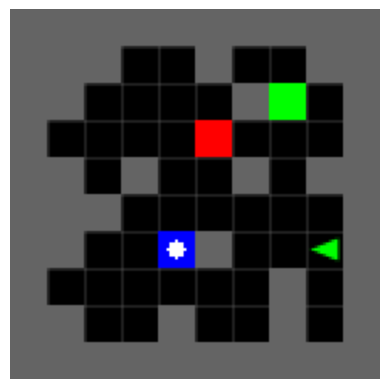

In [10]:
sample = train_data[0]
sample_all_obs = sample['all_obs']
sample_goal = sample['goal']
sample_goals = sample['goals']
sample_base_grid = sample['base_grid']
sample_width, sample_height = sample['base_grid'].shape
sample_grid = create_grid_from_base_grid(sample_base_grid, sample_goals)
sample_pos = sample_all_obs[0]['target_pos']
sample_dir = sample_all_obs[0]['target_dir']
sample_pos_state = (sample_pos, sample_dir)

sample_image = local_render(sample_grid, sample_width, sample_height, sample_pos_state, tile_size=13, goal_data=sample_goal)
display_image(sample_image)
sample_goal_desc = get_location_icon(sample_goal, sample_width, sample_image)



Image shape: (13, 13, 3)


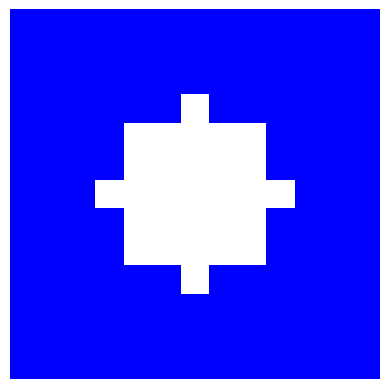

In [11]:
display_image(sample_goal_desc)

In [14]:
DIRECTION_TO_TEXT_DICT = {
    0: 'right',
    1: 'down',
    2: 'left',
    3: 'up'
}

dataset_dir_pattern = "/home/sukai/Project/chenyuan_project/new_multi_grid/data/training_data/actor_moves_dataset_single_image/{split}"

def obtain_data_dict_for_models(data_dict, split='train'):
    
    # add to data dict
    dict_name = f"data_dict_{split}"
    if dict_name in globals():
        data_dict_ = globals()[dict_name]
    else:
        raise ValueError(f"dict_name {dict_name} not found in locals()")
    
    id_count = 0 
    for scenario in tqdm(data_dict):
        all_obs = scenario['all_obs']
        goal = scenario['goal']
        goals = scenario['goals']
        base_grid = scenario['base_grid']
        width, height = base_grid.shape
        grid = create_grid_from_base_grid(base_grid, goals)
        
        goal_desc = None
        
        for t in range(len(all_obs)-1):
            current_obs = all_obs[t]
            next_obs = all_obs[t+1]
            
            current_pos = current_obs['target_pos']
            current_dir = current_obs['target_dir']
            current_pos_state = (current_pos, current_dir)
            
            
            target_action = DIRECTION_TO_TEXT_DICT[int(next_obs['target_dir'])]
            
            
            # render image
            image = local_render(grid, width, height, current_pos_state, tile_size=13, goal_data=goal)
            
            # get goal description
            if goal_desc is None:
                goal_desc = get_location_icon(goal, width, image)


            image_path = dataset_dir_pattern.format(split=split) + f"/{id_count}.png"
            relative_path = f"{split}/{id_count}.png"
            Path(image_path).parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(image_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
            # # save the goal image too 
            # goal_image_path = dataset_dir_pattern.format(split=split) + f"/icon_{id_count}.png"
            # goal_relative_path = f"{split}/icon_{id_count}.png"
            # cv2.imwrite(goal_image_path, cv2.cvtColor(goal_desc, cv2.COLOR_RGB2BGR))
            
            data_dict_['id'].append(id_count)
            data_dict_['image_path'].append(relative_path)
            # data_dict_['goal_description'].append(goal_relative_path)
            data_dict_['behavior_description'].append(int(scenario['hidden_cost_type']))
            data_dict_['action'].append(target_action)

            id_count += 1
            
            


In [15]:
obtain_data_dict_for_models(train_data, split='train')
obtain_data_dict_for_models(val_data, split='validation')
obtain_data_dict_for_models(test_data, split='test')

100%|██████████| 1031/1031 [00:41<00:00, 25.14it/s]


In [16]:
# save the dict as jsonl 
import jsonlines

# reset data_dict_train to list
data_dict_train_new = []

for i in range(len(data_dict_train['id'])):
    data_dict_train_new.append({
        'id': data_dict_train['id'][i],
        'image_path': data_dict_train['image_path'][i],
        # 'goal_description': data_dict_train['goal_description'][i],
        'behavior_description': data_dict_train['behavior_description'][i],
        'action': data_dict_train['action'][i]
    })
    
# shuffle the data_dict_train_new
import random
random.shuffle(data_dict_train_new)
    
data_dict_validation_new = []
for i in range(len(data_dict_validation['id'])):
    data_dict_validation_new.append({
        'id': data_dict_validation['id'][i],
        'image_path': data_dict_validation['image_path'][i],
        # 'goal_description': data_dict_validation['goal_description'][i],
        'behavior_description': data_dict_validation['behavior_description'][i],
        'action': data_dict_validation['action'][i]
    })
    
data_dict_test_new = []
for i in range(len(data_dict_test['id'])):
    data_dict_test_new.append({
        'id': data_dict_test['id'][i],
        'image_path': data_dict_test['image_path'][i],
        # 'goal_description': data_dict_test['goal_description'][i],
        'behavior_description': data_dict_test['behavior_description'][i],
        'action': data_dict_test['action'][i]
    })
    
jsonl_train_fp = Path(dataset_dir_pattern.format(split='train')) / "metainfo.jsonl"
jsonl_validation_fp = Path(dataset_dir_pattern.format(split='validation')) / "metainfo.jsonl"
jsonl_test_fp = Path(dataset_dir_pattern.format(split='test')) / "metainfo.jsonl"

with jsonlines.open(jsonl_train_fp, 'w') as writer:
    writer.write_all(data_dict_train_new)
    
with jsonlines.open(jsonl_validation_fp, 'w') as writer:
    writer.write_all(data_dict_validation_new)

with jsonlines.open(jsonl_test_fp, 'w') as writer:
    writer.write_all(data_dict_test_new)


In [17]:
# create README.md configs 

readme_fp = Path(dataset_dir_pattern.format(split='train')).parent / "README.md"

readme_content="""---
configs:
- config_name: default
  data_files:
  - split: train
    path: "train/metainfo.jsonl"
  - split: validation
    path: "validation/metainfo.jsonl"
  - split: test
    path: "test/metainfo.jsonl"
license: MIT
---
Sampled from Chenyuan Minigrid Active Goal Recognition Demonstrations for Actors
"""

with open(readme_fp, 'w') as f:
    f.write(readme_content)

## 2. Load the dataset and run with models

In [18]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from datasets import load_dataset
import os 
from PIL import Image

dataset_path = str(Path(dataset_dir_pattern.format(split='train')).parent)
dataset = load_dataset(dataset_path, split='test')




Generating train split: 297075 examples [00:00, 823013.62 examples/s]
Generating validation split: 6812 examples [00:00, 772602.12 examples/s]
Generating test split: 13789 examples [00:00, 1289009.05 examples/s]


In [19]:
dataset[0]

{'id': 0,
 'image_path': 'test/0.png',
 'behavior_description': 0,
 'action': 'left'}

In [20]:
from multigrid.gr_pursuer.agents.neuro_predictor import convert_to_conversation
def map_fn(sample):
    img_full_path = os.path.join(dataset_path, sample['image_path'])
    img = cv2.imread(img_full_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # goal_icon_full_path = os.path.join(dataset_path, sample['goal_description'])
    # goal_icon = cv2.imread(goal_icon_full_path)
    # goal_icon = cv2.cvtColor(goal_icon, cv2.COLOR_BGR2RGB)
    
    sample.update({
        'image': img,
        # 'goal_icon': goal_icon
    })
    return sample
    
dataset = dataset.map(map_fn)


Map: 100%|██████████| 13789/13789 [00:26<00:00, 514.19 examples/s]


Image shape: (130, 130, 3)


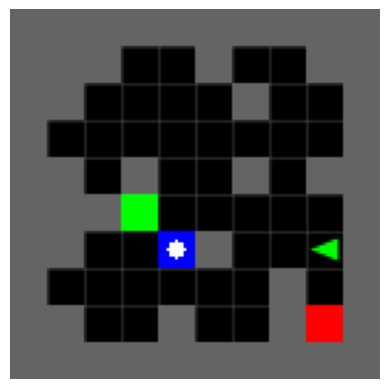

In [21]:
display_image(np.asarray(dataset[0]['image']))


In [22]:
sample = dataset[0]
conversation = convert_to_conversation(sample)
print(conversation)

KeyError: 'goal_icon'

In [45]:
print(conversation['messages'][1]['content'][0]['text'])

Task: Predict the next action.


Behavior type: 0

Observation: see the first image
Goal: see the second image

Format:
Return ONE action token from the allowed set. No extra words.

